In [9]:
from langgraph.graph import StateGraph, START, END, add_messages
from typing import TypedDict, Annotated, List
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
from langchain_community.tools import TavilySearchResults
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage

memory = MemorySaver()

search_tool = TavilySearchResults(max_results=2)
tools = [search_tool]

llm = ChatGroq(model="llama-3.1-8b-instant")
llm_with_tools = llm.bind_tools(tools=tools)

class BasicState(TypedDict): 
    messages: Annotated[List, add_messages]

def model(state: BasicState): 
    return {
        "messages": [llm_with_tools.invoke(state["messages"])]
    }

def tools_router(state: BasicState): 
    last_message = state["messages"][-1]
    if(hasattr(last_message, "tool_calls") and 
    len(last_message.tool_calls) > 0):
        return "tools"
    else: 
        return END


graph = StateGraph(BasicState)
graph.add_node(model, "model")
graph.add_node("tools", ToolNode(tools=tools))

graph.set_entry_point("model")
graph.add_conditional_edges("model", tools_router)

graph.add_edge("tools", "model")

app = graph.compile(checkpointer=memory, interrupt_before=["tools"])

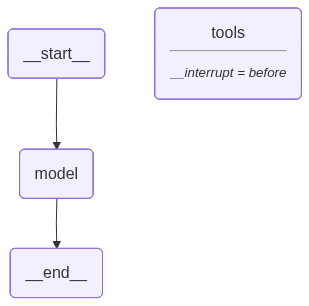

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [11]:

config = {"configurable": {
    "thread_id": 1
}}

events = app.stream({
    "messages": [HumanMessage(content="What is the current weather in Hyderabad?")]
}, config=config, stream_mode="values")

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the current weather in Hyderabad?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (ceh3gfsds)
 Call ID: ceh3gfsds
  Args:
    query: Hyderabad current weather


In [12]:
snapshot = app.get_state(config=config)
snapshot.next

('tools',)

In [13]:
events = app.stream(None, config, stream_mode="values")
for event in events:
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (ceh3gfsds)
 Call ID: ceh3gfsds
  Args:
    query: Hyderabad current weather
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.weather25.com/asia/india/andhra-pradesh/hyderabad?page=month&month=November", "content": "You can expect a few rainy days in Hyderabad during November, but usually the weather is comfortable in November.\n\nOur weather forecast can give you a great sense of what weather to expect in Hyderabad in November 2025.\n\nIf you’re planning to visit Hyderabad in the near future, we highly recommend that you review the 14 day weather forecast for Hyderabad before you arrive.\n\nTemperatures\nRainy Days\nSnowy Days\nDry Days\nRainfall\n11.1 [...] weather25.com\nSearch\nweather in India\nRemove from your favorite locations\nAdd to my locations\nShare\nweather in India